# Actividad 1 — Diagnóstico, limpieza y transformación de datos
### Algoritmos de aprendizaje automático


#Agregué todas las instrucciones de canvas para ir paso a paso y que esté todo en la act, por eso se ve muy extenso el notebook

Al inicio del notebook, deberás registrar el nombre del dataset, la fuente, la liga de acceso, la fecha de consulta, la fecha de última actualización reportada en Kaggle y una breve descripción del contexto que representa. Asimismo, deberás explicar qué significa cada registro, cuál podría ser la variable objetivo, qué tipo de problema de aprendizaje automático podría abordarse y qué utilidad tendría un modelo construido con esos datos

## 1. Contextualización del dataset

**Nombre:** Student Performance Factors Dataset  
**Fuente / Autor:** Abdel-Ghany, M. (2025), Kaggle  
**Liga:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  
**Fecha de consulta:** 15 de agosto de 2026  
**Última actualización en Kaggle:** Octubre de 2025  
**Descripción:** 6,607 registros de estudiantes con factores académicos, personales, familiares y escolares (horas de estudio, asistencia, involucramiento parental, calidad del docente, etc.) y su puntaje final de examen.

**¿Qué representa cada registro?** Cada fila es un estudiante, descrito por 19 factores + 1 resultado (`Exam_Score`).

**Variable objetivo:** `Exam_Score` (puntaje de examen, numérico).

**Tipo de problema:** Regresión supervisada (predecir un número continuo).

**Utilidad del modelo:** estimar el puntaje esperado de un estudiante según sus hábitos y contexto, para detectar a tiempo a quienes están en riesgo y orientar apoyos (tutorías, recursos).

Carga el conjunto de datos y revisar su estructura general. Deberás identificar el número de filas y columnas, los nombres de las variables, los tipos de datos, la cantidad de valores faltantes, los registros duplicados y el número de valores únicos por columna. Además, deberás complementar esta revisión con estadísticas descriptivas y una muestra de los registros. A partir de esta exploración, deberás redactar una interpretación breve sobre el estado inicial del dataset.

In [14]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("\nNombres de variables:")
print(list(df.columns))

resumen = pd.DataFrame({
    "Tipo de dato": df.dtypes.astype(str),
    "Faltantes": df.isnull().sum(),
    "Valores únicos": df.nunique()
})
print("\nRevisión por columna:")
print(resumen)

print("\nFilas duplicadas:", df.duplicated().sum())
print("Total de valores faltantes:", df.isnull().sum().sum())

Filas: 6607 | Columnas: 20

Nombres de variables:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Revisión por columna:
                           Tipo de dato  Faltantes  Valores únicos
Hours_Studied                     int64          0              41
Attendance                        int64          0              41
Parental_Involvement             object          0               3
Access_to_Resources              object          0               3
Extracurricular_Activities       object          0               2
Sleep_Hours                       int64          0               7
Previous_Scores                   int64          0              51

### Interpretación del estado inicial

- El dataset tiene **6,607 filas y 20 columnas**: 7 numéricas y 13 categóricas.
- **No hay filas duplicadas.**
- Hay **235 valores faltantes** en 3 variables categóricas: `Teacher_Quality` (78), `Parental_Education_Level` (90) y `Distance_from_Home` (67).
- Las categorías se ven **consistentes**, sin espacios extra ni formatos mezclados.
- **Alerta:** `Exam_Score` tiene un máximo de **101**, cuando el valor válido debe ser máximo 100. Esto se corrige en la etapa de limpieza.

En general el dataset está en buen estado, pero requiere eliminar faltantes y corregir ese valor imposible antes de modelar.

Después, deberás analizar los principales problemas de calidad. Considera valores faltantes, duplicados, tipos de datos incorrectos, categorías inconsistentes, espacios adicionales, columnas numéricas almacenadas como texto, valores extremos, rangos imposibles, variables constantes o identificadores que no aporten información útil. Los hallazgos deberán organizarse en una tabla

In [15]:
#Problemas de calidad
print("Faltantes:\n", df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicados:", df.duplicated().sum())

# Rango imposible en la variable objetivo
print("\nExam_Score > 100:", (df["Exam_Score"] > 100).sum(), "registro(s)")
print("Máximo de Exam_Score:", df["Exam_Score"].max())

# Columnas constantes
print("\nColumnas constantes:", [c for c in df.columns if df[c].nunique() <= 1])

Faltantes:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplicados: 0

Exam_Score > 100: 1 registro(s)
Máximo de Exam_Score: 101

Columnas constantes: []


### Diagnóstico de calidad de datos

| Problema detectado | Variable afectada | Evidencia | Tratamiento propuesto |
|---|---|---|---|
| Valores faltantes | `Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home` | 78 / 90 / 67 nulos (≈1.2% c/u) | Imputar con la moda |
| Rango imposible | `Exam_Score` | 1 registro con valor 101 (máximo válido = 100) | Eliminar ese registro |
| Nombres de columnas | Todas | Mezcla de mayúsculas/minúsculas | Estandarizar a minúsculas |
| Espacios adicionales | Categóricas | No se detectaron; se aplica `.strip()` preventivo | Limpieza preventiva |
| Duplicados | — | 0 filas duplicadas | No aplica |
| Tipos de dato / num como texto | — | Numéricas ya son `int`, categóricas ya son texto | No requiere conversión |
| Variables constantes / identificadores | — | Ninguna columna constante ni ID inútil | No aplica |
| Valores extremos (outliers) | `Hours_Studied`, `Tutoring_Sessions` | Valores altos por IQR, pero plausibles | Conservar  |

Con base en este diagnóstico, deberás aplicar una limpieza básica. Corrige nombres de columnas, elimina duplicados, convierte tipos de datos, estandariza categorías, trata valores faltantes y filtra valores imposibles cuando sea necesario. Cada modificación deberá justificarse dentro del notebook, explicando qué problema atiende y cómo cambia el conjunto de datos. No deberán eliminarse registros o columnas sin una razón clara.

In [16]:
df_limpio = df.copy()
estado_inicial = {
    "registros": df_limpio.shape[0],
    "variables": df_limpio.shape[1],
    "faltantes": int(df_limpio.isnull().sum().sum()),
    "duplicados": int(df_limpio.duplicated().sum())
}
print("Estado inicial:", estado_inicial)

Estado inicial: {'registros': 6607, 'variables': 20, 'faltantes': 235, 'duplicados': 0}


In [17]:
df_limpio.columns = df_limpio.columns.str.strip().str.lower()
print(list(df_limpio.columns))

['hours_studied', 'attendance', 'parental_involvement', 'access_to_resources', 'extracurricular_activities', 'sleep_hours', 'previous_scores', 'motivation_level', 'internet_access', 'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'physical_activity', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender', 'exam_score']


In [18]:
antes = df_limpio.shape[0]
df_limpio = df_limpio.drop_duplicates()
print("Duplicados eliminados:", antes - df_limpio.shape[0])

for c in df_limpio.select_dtypes(include="object").columns:
    df_limpio[c] = df_limpio[c].str.strip()
print("Espacios eliminados.")

for c in ["teacher_quality", "parental_education_level", "distance_from_home"]:
    moda = df_limpio[c].mode()[0]
    n = df_limpio[c].isnull().sum()
    df_limpio[c] = df_limpio[c].fillna(moda)
    print(f"{c}: {n} faltantes imputados con '{moda}'")
print("Faltantes restantes:", int(df_limpio.isnull().sum().sum()))

Duplicados eliminados: 0
Espacios eliminados.
teacher_quality: 78 faltantes imputados con 'Medium'
parental_education_level: 90 faltantes imputados con 'High School'
distance_from_home: 67 faltantes imputados con 'Near'
Faltantes restantes: 0


In [12]:
antes = df_limpio.shape[0]
df_limpio = df_limpio[df_limpio["exam_score"] <= 100]
print("Registros eliminados por exam_score > 100:", antes - df_limpio.shape[0])
print("Nuevo rango de exam_score:", df_limpio["exam_score"].min(), "a", df_limpio["exam_score"].max())

Registros eliminados por exam_score > 100: 1
Nuevo rango de exam_score: 55 a 100


### Resumen de la limpieza aplicada

1. **Nombres de columnas** estandarizados a minúsculas
2. **Duplicados** 0 eliminados poruqe no había.
3. **Espacios** recorte preventivo en variables de texto.
4. **Faltantes** imputados con la moda; el dataset queda **sin nulos** y conserva todos los registros.
5. **Rango imposible** se eliminó **1** registro con `exam_score = 101` ya que era un valor inválido en la variable objetivo.


Selecciona la variable Exam_Score como variable de interés que pudiera utilizarse posteriormente como objetivo. Debido a que se trata de una variable numérica, deberás calcular sus medidas descriptivas y representar su distribución mediante un histograma o un diagrama de caja. Asimismo, deberás explicar qué indica la distribución, si existen valores atípicos y si se identifica algún problema que pudiera afectar el modelado posterior.

count    6606.00
mean       67.23
std         3.87
min        55.00
25%        65.00
50%        67.00
75%        69.00
max       100.00
Name: exam_score, dtype: float64


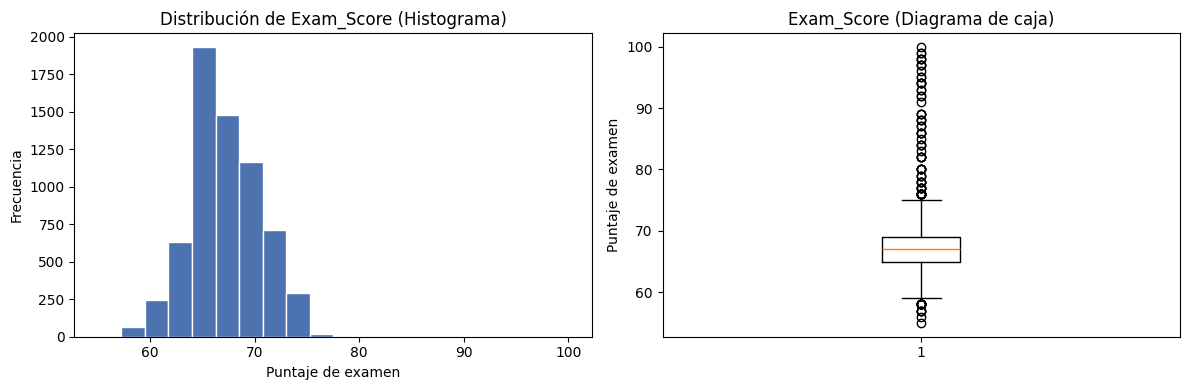

In [13]:
import matplotlib.pyplot as plt

# Medidas descriptivas
print(df_limpio["exam_score"].describe().round(2))

# Histograma + diagrama de caja
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_limpio["exam_score"], bins=20, color="#4C72B0", edgecolor="white")
ax[0].set_title("Distribución de Exam_Score (Histograma)")
ax[0].set_xlabel("Puntaje de examen")
ax[0].set_ylabel("Frecuencia")

ax[1].boxplot(df_limpio["exam_score"])
ax[1].set_title("Exam_Score (Diagrama de caja)")
ax[1].set_ylabel("Puntaje de examen")

plt.tight_layout()
plt.show()

### Interpretación de Exam_Score

- `exam_score` se concentra alrededor de **65–69** (media ≈ 67, mediana = 67), con muy poca dispersión (desv. est. ≈ 3.9).
- La distribución es **casi simétrica**, con una **cola derecha** de pocos estudiantes con puntajes altos (hasta 100).
- Esos valores altos aparecen como **puntos atípicos** en el diagrama de caja, pero son **válidos** (no imposibles), así que se conservan.
- **Problema a considerar para el modelado:** la **baja variabilidad** de la variable objetivo (casi todo entre 65 y 69) puede dificultar que un modelo distinga bien el desempeño entre estudiantes.

Amplia la exploración con al menos dos variables numéricas y dos variables categóricas. Para las variables numéricas, deberás revisar estadísticas, distribución y posibles valores atípicos. Se pueden considerar variables como Hours_Studied, Attendance, Sleep_Hours, Previous_Scores o Tutoring_Sessions. Para las variables categóricas, analizarás frecuencias, categorías poco comunes e inconsistencias. Se pueden considerar variables como Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Internet_Access, Learning_Disabilities o Gender. Deberás incluir al menos tres visualizaciones pertinentes en total. Cada gráfica deberá tener título, etiquetas y una interpretación breve que explique qué aporta al diagnóstico.


**4 variables: Hours_Studied y Attendance (numéricas) + Family_Income y Teacher_Quality (categóricas).**

hours_studied:
 count    6607.00
mean       19.98
std         5.99
min         1.00
25%        16.00
50%        20.00
75%        24.00
max        44.00
Name: hours_studied, dtype: float64 

attendance:
 count    6607.00
mean       79.98
std        11.55
min        60.00
25%        70.00
50%        80.00
75%        90.00
max       100.00
Name: attendance, dtype: float64


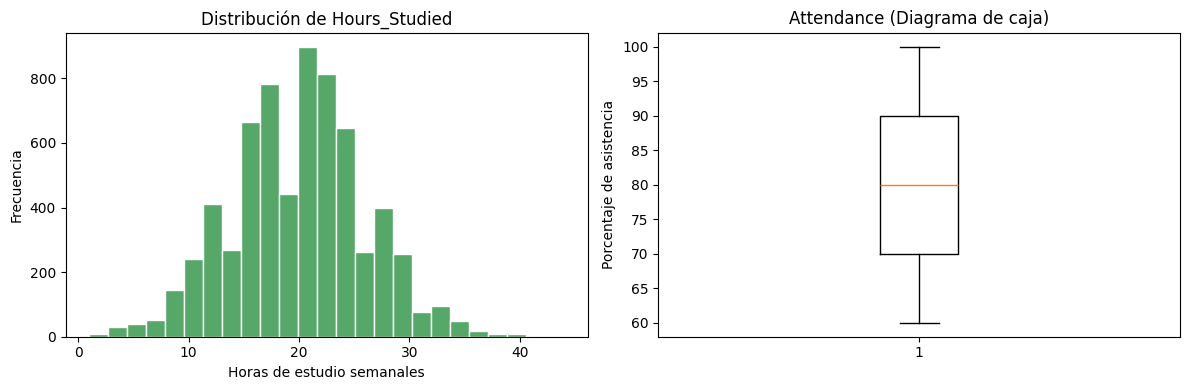

In [19]:
# Numéricas
print("hours_studied:\n", df_limpio["hours_studied"].describe().round(2), "\n")
print("attendance:\n", df_limpio["attendance"].describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_limpio["hours_studied"], bins=25, color="#55A868", edgecolor="white")
ax[0].set_title("Distribución de Hours_Studied")
ax[0].set_xlabel("Horas de estudio semanales")
ax[0].set_ylabel("Frecuencia")

ax[1].boxplot(df_limpio["attendance"])
ax[1].set_title("Attendance (Diagrama de caja)")
ax[1].set_ylabel("Porcentaje de asistencia")

plt.tight_layout()
plt.show()

### Interpretación

- **Hours_Studied** se distribuye de forma aproximadamente normal, centrada en ~20 h, con algunos valores altos (hasta 44 h) que son atípicos pero **posibles**, por lo que se conservan.
- **Attendance** va de 60 a 100 de manera bastante uniforme, **sin valores atípicos ni imposibles**. Es una variable limpia.

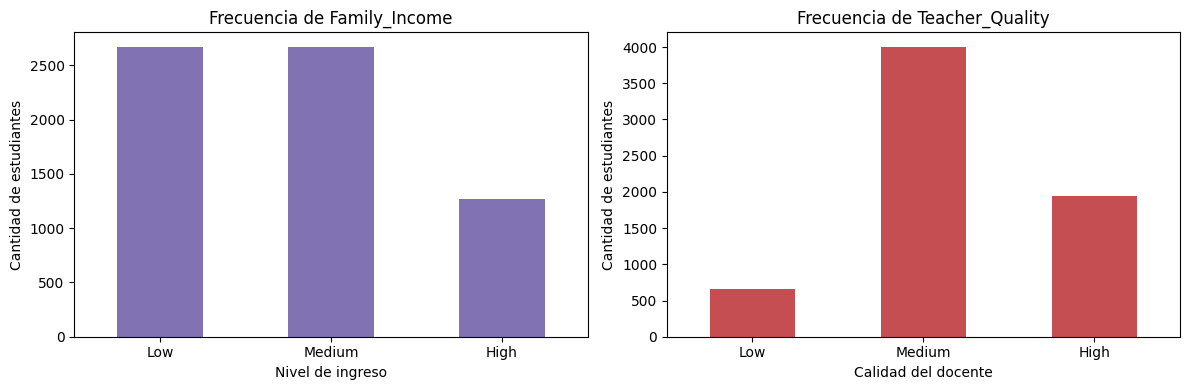

family_income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

teacher_quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64


In [20]:
#Categóricas
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df_limpio["family_income"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", ax=ax[0], color="#8172B3")
ax[0].set_title("Frecuencia de Family_Income")
ax[0].set_xlabel("Nivel de ingreso")
ax[0].set_ylabel("Cantidad de estudiantes")
ax[0].tick_params(axis="x", rotation=0)

df_limpio["teacher_quality"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("Frecuencia de Teacher_Quality")
ax[1].set_xlabel("Calidad del docente")
ax[1].set_ylabel("Cantidad de estudiantes")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(df_limpio["family_income"].value_counts())
print()
print(df_limpio["teacher_quality"].value_counts())

### Interpretación (categóricas)

- **Family_Income** tiene 3 categorías ordenadas (Low/Medium/High). Predomina **Medium**, seguido de Low y High. Sin categorías raras ni inconsistencias.
- **Teacher_Quality** también tiene 3 niveles y predomina **Medium**. Esta variable tenía valores faltantes que ya fueron imputados con la moda en la limpieza, por lo que ahora está completa.

Con esto se cumplen **3 visualizaciones** en total

A continuación, deberás seleccionar al menos dos variables categóricas y convertirlas a una representación numérica. Utiliza One-Hot Encoding para variables nominales, como School_Type, Internet_Access o Gender, y codificación ordinal cuando la variable tenga un orden claro, como Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality o Distance_from_Home. Además, deberás explicar por qué se eligió ese método y qué diferencia existe entre representar categorías nominales y variables que sí poseen un orden.

In [21]:
# Ordinal
orden = {"Low": 0, "Medium": 1, "High": 2}

df_limpio["family_income_cod"] = df_limpio["family_income"].map(orden)
df_limpio["teacher_quality_cod"] = df_limpio["teacher_quality"].map(orden)

print(df_limpio[["family_income", "family_income_cod",
                 "teacher_quality", "teacher_quality_cod"]].head())

  family_income  family_income_cod teacher_quality  teacher_quality_cod
0           Low                  0          Medium                    1
1        Medium                  1          Medium                    1
2        Medium                  1          Medium                    1
3        Medium                  1          Medium                    1
4        Medium                  1            High                    2


In [22]:
# One hot variables nominales
df_limpio = pd.get_dummies(df_limpio,
                           columns=["school_type", "gender"],
                           drop_first=True)

# Columnas nuevas que se crearon
print([c for c in df_limpio.columns if "school_type" in c or "gender" in c])
df_limpio.head(3)

['school_type_Public', 'gender_Male']


,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,...,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,exam_score,family_income_cod,teacher_quality_cod,school_type_Public,gender_Male
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,67,0,1,True,True
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,61,1,1,True,False
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,74,1,1,True,True


### Codificación de variables categóricas

- **Ordinal** (`family_income`, `teacher_quality`): tienen un orden natural (Low < Medium < High), así que se asigna un número que respeta ese orden (0, 1, 2). Un solo número conserva la información de jerarquía.
- **One-Hot** (`school_type`, `gender`): son nominales, no tienen orden. Se crea una columna por categoría (0/1), para no inventar una jerarquía que no existe.

**Diferencia clave:** en una variable **nominal** los valores no se pueden ordenar asi que si les pusiéramos 0, 1, 2 el modelo pensaría que una categoría vale más que otra, lo cual sería falso, por eso se usa One-Hot. En una variable **ordinal** sí existe un orden real, así que un número que lo respete sí aporta información útil al modelo.

Selecciona al menos dos variables numéricas y aplica una técnica de escalamiento, como StandardScaler, MinMaxScaler o RobustScaler. Se pueden utilizar variables como Hours_Studied, Attendance, Sleep_Hours, Previous_Scores o Tutoring_Sessions. Deberás comparar los valores antes y después de la transformación, así como explicar qué cambia, qué información se conserva y por qué algunos algoritmos de aprendizaje automático son sensibles a la escala de las variables.

In [24]:
from sklearn.preprocessing import StandardScaler

num = ["hours_studied", "attendance"]

print("Antes del escalamiento:")
print(df_limpio[num].describe().loc[["mean", "std", "min", "max"]].round(2))

Antes del escalamiento:
      hours_studied  attendance
mean          19.98       79.98
std            5.99       11.55
min            1.00       60.00
max           44.00      100.00


In [25]:
scaler = StandardScaler()
escaladas = pd.DataFrame(scaler.fit_transform(df_limpio[num]),
                         columns=[c + "_esc" for c in num])

print("Despues del escalamiento:")
print(escaladas.describe().loc[["mean", "std", "min", "max"]].round(2))

comparacion = pd.concat([df_limpio[num].reset_index(drop=True), escaladas], axis=1)
comparacion.head()

Despues del escalamiento:
      hours_studied_esc  attendance_esc
mean              -0.00           -0.00
std                1.00            1.00
min               -3.17           -1.73
max                4.01            1.73


,hours_studied,attendance,hours_studied_esc,attendance_esc
0,23,84,0.504942,0.348375
1,19,64,-0.162822,-1.383736
2,24,98,0.671882,1.560853
3,29,89,1.506587,0.781403
4,19,92,-0.162822,1.041220


### Escalamiento con StandardScaler

**Qué cambia:** antes, `hours_studied` iba de 1 a 44 y `attendance` de 60 a 100, en escalas distintas. Después del escalamiento, ambas quedan con **media ≈ 0 y desviación ≈ 1**, compartiendo la misma escala.

**Qué se conserva:** la **forma de la distribución** y el **orden relativo** entre los valores. Un estudiante que estudiaba más horas que otro sigue teniendo un valor mayor; solo cambia la unidad de medida, no la información.

**Por qué importa:** algunos algoritmos son ensibles a la escala porque usan distancias o gradientes. Sin escalar, `attendance`pesaría más que otra variable con valores pequeños solo por su magnitud, no por su importancia real. Al escalar, todas las variables compiten en igualdad de condiciones.

Organiza las transformaciones de forma reproducible. De preferencia, deberás utilizar ColumnTransformer o Pipeline de Scikit-learn para separar el tratamiento de variables numéricas y categóricas. En caso de no utilizar estas herramientas, deberás presentar una tabla técnica que indique las variables tratadas, la transformación aplicada y la justificación. Asimismo, deberás aclarar que, en una etapa posterior de modelado, la codificación y el escalamiento deberán ajustarse únicamente con los datos de entrenamiento para evitar fuga de información.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

target = "exam_score"

# Numéricas-escalar
num_cols = ["hours_studied", "attendance", "sleep_hours",
            "previous_scores", "tutoring_sessions", "physical_activity"]

# Ordinales.-codificación ordinal
ord_cols = ["parental_involvement", "access_to_resources", "motivation_level",
            "family_income", "teacher_quality", "distance_from_home",
            "peer_influence", "parental_education_level"]
ord_orden = [["Low","Medium","High"], ["Low","Medium","High"], ["Low","Medium","High"],
             ["Low","Medium","High"], ["Low","Medium","High"], ["Near","Moderate","Far"],
             ["Negative","Neutral","Positive"], ["High School","College","Postgraduate"]]

# Nominales-One-Hot
nom_cols = ["school_type", "internet_access", "gender",
            "extracurricular_activities", "learning_disabilities"]

print("Numéricas:", len(num_cols), "Ordinales:", len(ord_cols), "Nominales:", len(nom_cols))

Numéricas: 6 Ordinales: 8 Nominales: 5


In [31]:
# Reconstruir base
df_base = df.copy()
df_base.columns = df_base.columns.str.strip().str.lower()
df_base = df_base.drop_duplicates()
for c in df_base.select_dtypes(include="object").columns:
    df_base[c] = df_base[c].str.strip()
for c in ["teacher_quality", "parental_education_level", "distance_from_home"]:
    df_base[c] = df_base[c].fillna(df_base[c].mode()[0])
df_base = df_base[df_base["exam_score"] <= 100]

print("Base lista:", df_base.shape)

Base lista: (6606, 20)


In [32]:
preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler())
    ]), num_cols),
    ("ord", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=ord_orden))
    ]), ord_cols),
    ("nom", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
    ]), nom_cols),
])


X = df_base.drop(columns=[target])
y = df_base[target]

X_trans = preprocesador.fit_transform(X)
nombres = preprocesador.get_feature_names_out()

X_final = pd.DataFrame(X_trans, columns=nombres, index=df_base.index)
print("Forma de X transformado:", X_final.shape)
X_final.head()

Forma de X transformado: (6606, 19)


,num__hours_studied,num__attendance,num__sleep_hours,num__previous_scores,num__tutoring_sessions,num__physical_activity,ord__parental_involvement,ord__access_to_resources,ord__motivation_level,ord__family_income,ord__teacher_quality,ord__distance_from_home,ord__peer_influence,ord__parental_education_level,nom__school_type_Public,nom__internet_access_Yes,nom__gender_Male,nom__extracurricular_activities_Yes,nom__learning_disabilities_Yes
0,0.505133,0.348650,-0.019901,-0.143617,-1.214158,0.031414,0.0,2.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0
1,-0.162650,-1.383650,0.661268,-1.115968,0.412105,1.001129,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
2,0.672079,1.561259,-0.019901,1.106548,0.412105,1.001129,1.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0
3,1.506808,0.781725,0.661268,1.592723,-0.401027,1.001129,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
4,-0.162650,1.041570,-0.701069,-0.699247,1.225236,1.001129,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0




Se usó un **ColumnTransformer** que separa el tratamiento por tipo de variable: imputación + escalado (numéricas), imputación + ordinal (ordinales) e imputación + One-Hot (nominales). Esto hace el proceso ordenado y reproducible.


Resumir el resultado de las transformaciones mediante una comparación del estado inicial y final del dataset:


In [33]:

df_final = X_final.copy()
df_final[target] = y.values

comparacion = pd.DataFrame({
    "Estado inicial": [
        df.shape[0],
        df.shape[1],
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        "0 (todas en texto)",
        "0 (sin escalar)"
    ],
    "Estado final": [
        df_final.shape[0],
        df_final.shape[1],
        int(df_final.isnull().sum().sum()),
        int(df_final.duplicated().sum()),
        f"{len(ord_cols)} ordinales + {len(nom_cols)} nominales (One-Hot)",
        f"{len(num_cols)} escaladas (StandardScaler)"
    ]
}, index=[
    "Número de registros", "Número de variables", "Valores faltantes",
    "Registros duplicados", "Variables categóricas transformadas",
    "Variables numéricas escaladas"
])

comparacion

,Estado inicial,Estado final
Número de registros,6607,6606
Número de variables,20,20
Valores faltantes,235,0
Registros duplicados,0,0
Variables categóricas transformadas,0 (todas en texto),8 ordinales + 5 nominales (One-Hot)
Variables numéricas escaladas,0 (sin escalar),6 escaladas (StandardScaler)


Verifica que los datos puedan cargarse y utilizarse sin errores después de la limpieza. Deberás exportar una versión preparada en formato CSV con un nombre que permita distinguirla del archivo original, por ejemplo, csv. El archivo exportado deberá conservar la variable objetivo y las variables preparadas para una etapa posterior de modelado.


Finaliza el notebook con una conclusión en la que se integren los principales problemas identificados, las transformaciones más relevantes, el efecto de la codificación y el escalamiento, alguna limitación que todavía conserve el dataset y el siguiente paso que debería realizarse antes de entrenar un modelo.

In [34]:
salida = "StudentPerformanceFactors_archivoyamodificaod.csv"
df_final.to_csv(salida, index=False)
print("Archivo exportado:", salida)

prueba = pd.read_csv(salida)
print("Recarga correcta. Forma:", prueba.shape)
print("¿Contiene la variable objetivo 'exam_score'?", "exam_score" in prueba.columns)
print("¿Valores faltantes?", int(prueba.isnull().sum().sum()))
prueba.head(3)

Archivo exportado: StudentPerformanceFactors_archivoyamodificaod.csv
Recarga correcta. Forma: (6606, 20)
¿Contiene la variable objetivo 'exam_score'? True
¿Valores faltantes? 0


,num__hours_studied,num__attendance,num__sleep_hours,num__previous_scores,num__tutoring_sessions,num__physical_activity,ord__parental_involvement,ord__access_to_resources,ord__motivation_level,ord__family_income,ord__teacher_quality,ord__distance_from_home,ord__peer_influence,ord__parental_education_level,nom__school_type_Public,nom__internet_access_Yes,nom__gender_Male,nom__extracurricular_activities_Yes,nom__learning_disabilities_Yes,exam_score
0,0.505133,0.348650,-0.019901,-0.143617,-1.214158,0.031414,0.0,2.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,0.412105,1.001129,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,0.412105,1.001129,1.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0,74


## Conclusión

El dataset venía bastante limpio, sin duplicados. Los dos problemas reales fueron 235 datos faltantes en tres variables y un valor imposible (un `exam_score` de 101, cuando el máximo es 100).

Para arreglarlo, rellené los faltantes con la moda, quité ese registro inválido, pasé todas las categorías a números (ordinal cuando había orden, One-Hot cuando no) y escalé las variables numéricas con un ColumnTransformer. Codificar deja que los algoritmos entiendan los datos, y escalar evita que una variable pese más solo por tener números más grandes.

Lo que le falta al dataset es variación en la variable objetivo: casi todos los puntajes caen entre 65 y 69, lo que puede complicar que un modelo distinga bien entre estudiantes.

El siguiente paso es dividir en entrenamiento y prueba, ajustar las transformaciones solo con los de entrenamiento (para no filtrar información) y probar un modelo de regresión sencillo como punto de partida.

### Fuentes consultadas
- Abdel-Ghany, M. (2025). *Student Performance Factors Dataset*. Kaggle. https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
- Documentación de Scikit-learn: ColumnTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder.